In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

RAW_PATH = "PDB_Load_History.csv"
PREPARED_PATH = "PDB_Load_History_prepared.csv"

df = pd.read_csv(RAW_PATH)
df.head()

,date,year,month,day,weekday,hour,demand,temperature
0,3/1/2003,2003,3,1,7,1,12863.0,29
1,3/1/2003,2003,3,1,7,2,12389.0,28
2,3/1/2003,2003,3,1,7,3,12155.0,29
3,3/1/2003,2003,3,1,7,4,12072.0,27
4,3/1/2003,2003,3,1,7,5,12160.0,29


In [2]:
print("Размер исходного набора:", df.shape)

print("\nПропуски:")
display(df.isna().sum().to_frame("missing_count"))

Размер исходного набора: (103776, 8)

Пропуски:


,missing_count
date,0
year,0
month,0
day,0
weekday,0
hour,0
demand,0
temperature,0


In [3]:
df["datetime"] = pd.to_datetime(df["date"], format="%m/%d/%Y") + pd.to_timedelta(df["hour"] - 1, unit="h")

prepared = df.loc[:, ["datetime", "demand"]].copy()
prepared = prepared.sort_values("datetime").reset_index(drop=True)

print("Диапазон дат:", prepared["datetime"].min(), "—", prepared["datetime"].max())

display(prepared.head())

Диапазон дат: 2003-03-01 00:00:00 — 2014-12-31 23:00:00


,datetime,demand
0,2003-03-01 00:00:00,12863.0
1,2003-03-01 01:00:00,12389.0
2,2003-03-01 02:00:00,12155.0
3,2003-03-01 03:00:00,12072.0
4,2003-03-01 04:00:00,12160.0


In [4]:
prepared.to_csv(PREPARED_PATH, index=False, date_format="%Y-%m-%d %H:%M:%S")
print(f"Файл сохранён: {PREPARED_PATH}")

Файл сохранён: PDB_Load_History_prepared.csv


In [5]:
display(prepared["demand"].describe().to_frame().T)

daily = prepared.set_index("datetime")["demand"].resample("D").mean()
monthly = prepared.set_index("datetime")["demand"].resample("ME").mean()

print("Среднесуточный ряд:", daily.shape)
print("Среднемесячный ряд:", monthly.shape)

,count,mean,std,min,25%,50%,75%,max
demand,103776.0,14674.947493,2894.54413,7794.0,12514.0,14773.0,16443.0,27622.0


Среднесуточный ряд: (4324,)
Среднемесячный ряд: (142,)


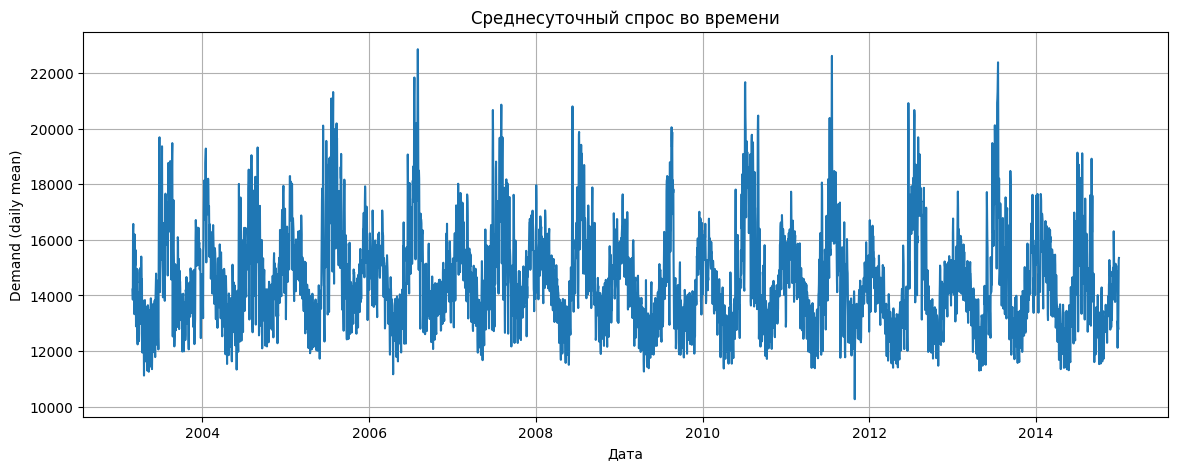

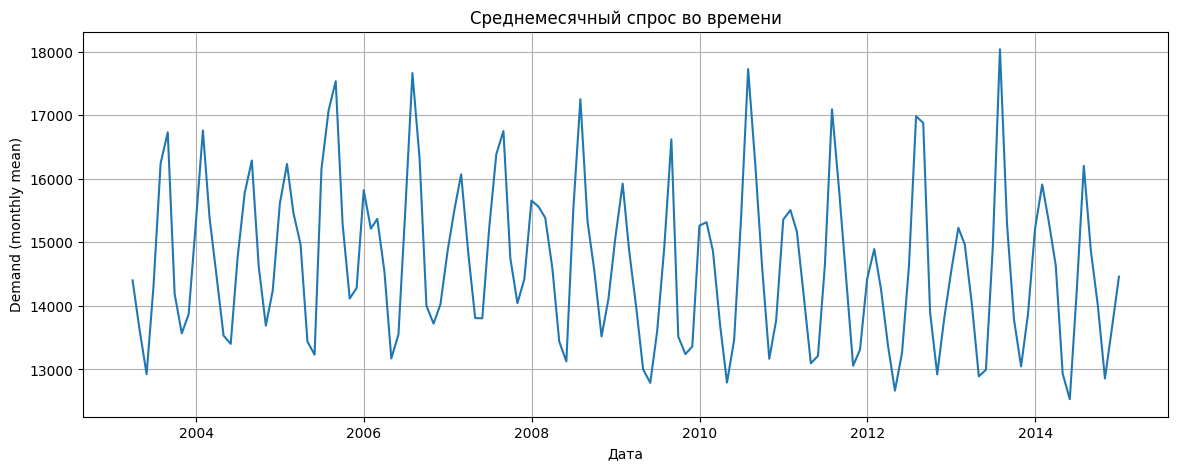

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily.values)
ax.set_title("Среднесуточный спрос во времени")
ax.set_xlabel("Дата")
ax.set_ylabel("Demand (daily mean)")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly.values)
ax.set_title("Среднемесячный спрос во времени")
ax.set_xlabel("Дата")
ax.set_ylabel("Demand (monthly mean)")
plt.show()

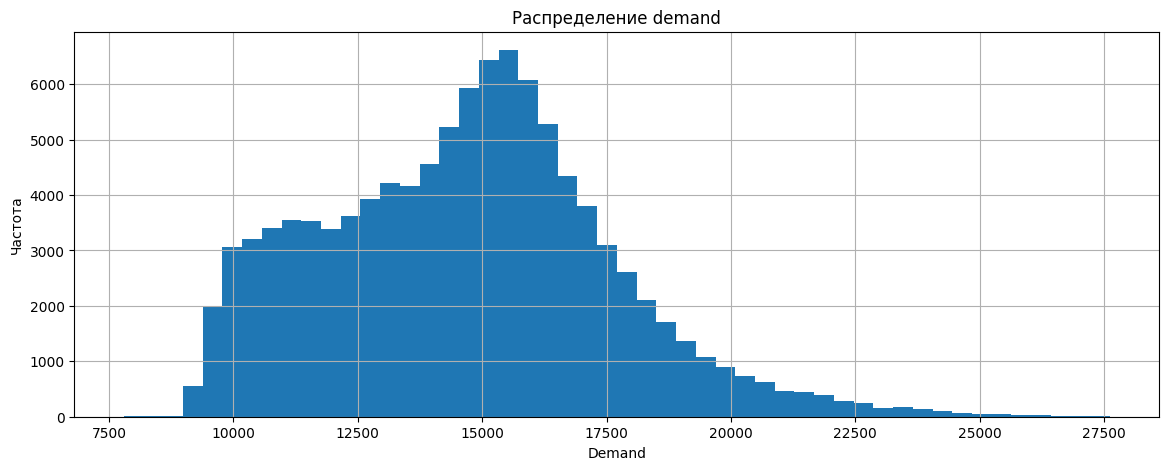

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(prepared["demand"], bins=50)
ax.set_title("Распределение demand")
ax.set_xlabel("Demand")
ax.set_ylabel("Частота")
plt.show()

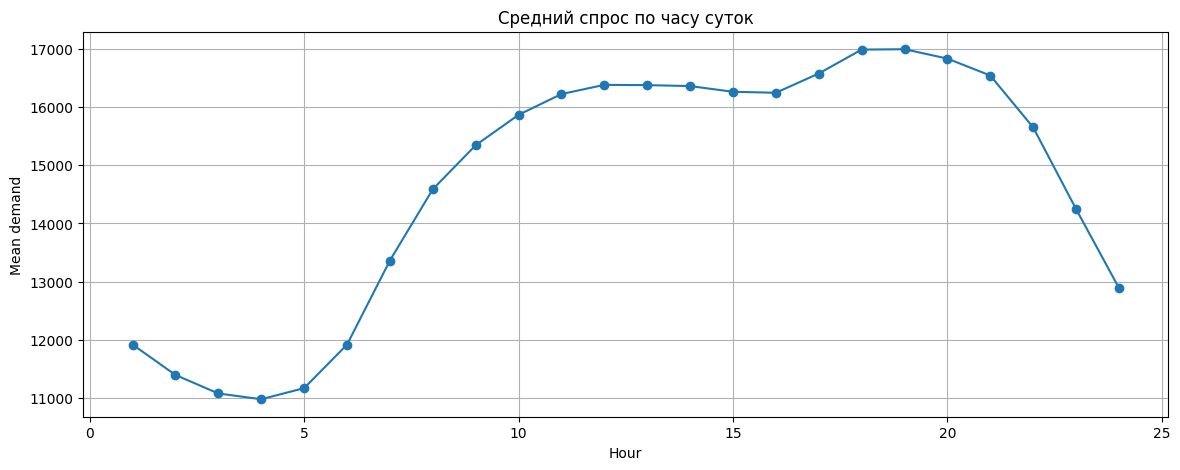

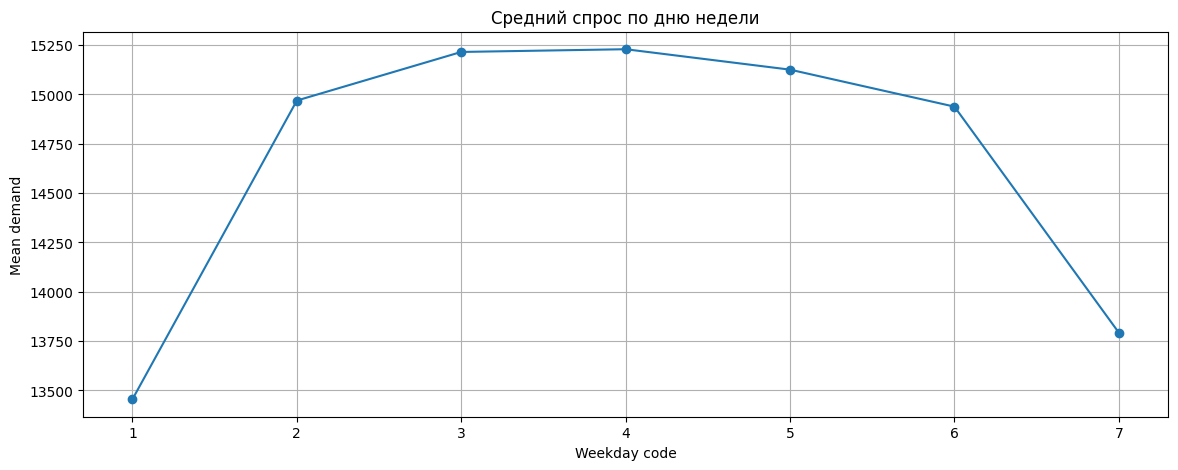

In [8]:
hourly_profile = df.groupby("hour")["demand"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly_profile.index, hourly_profile.values, marker="o")
ax.set_title("Средний спрос по часу суток")
ax.set_xlabel("Hour")
ax.set_ylabel("Mean demand")
plt.show()

weekday_profile = df.groupby("weekday")["demand"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekday_profile.index, weekday_profile.values, marker="o")
ax.set_title("Средний спрос по дню недели")
ax.set_xlabel("Weekday code")
ax.set_ylabel("Mean demand")
plt.show()

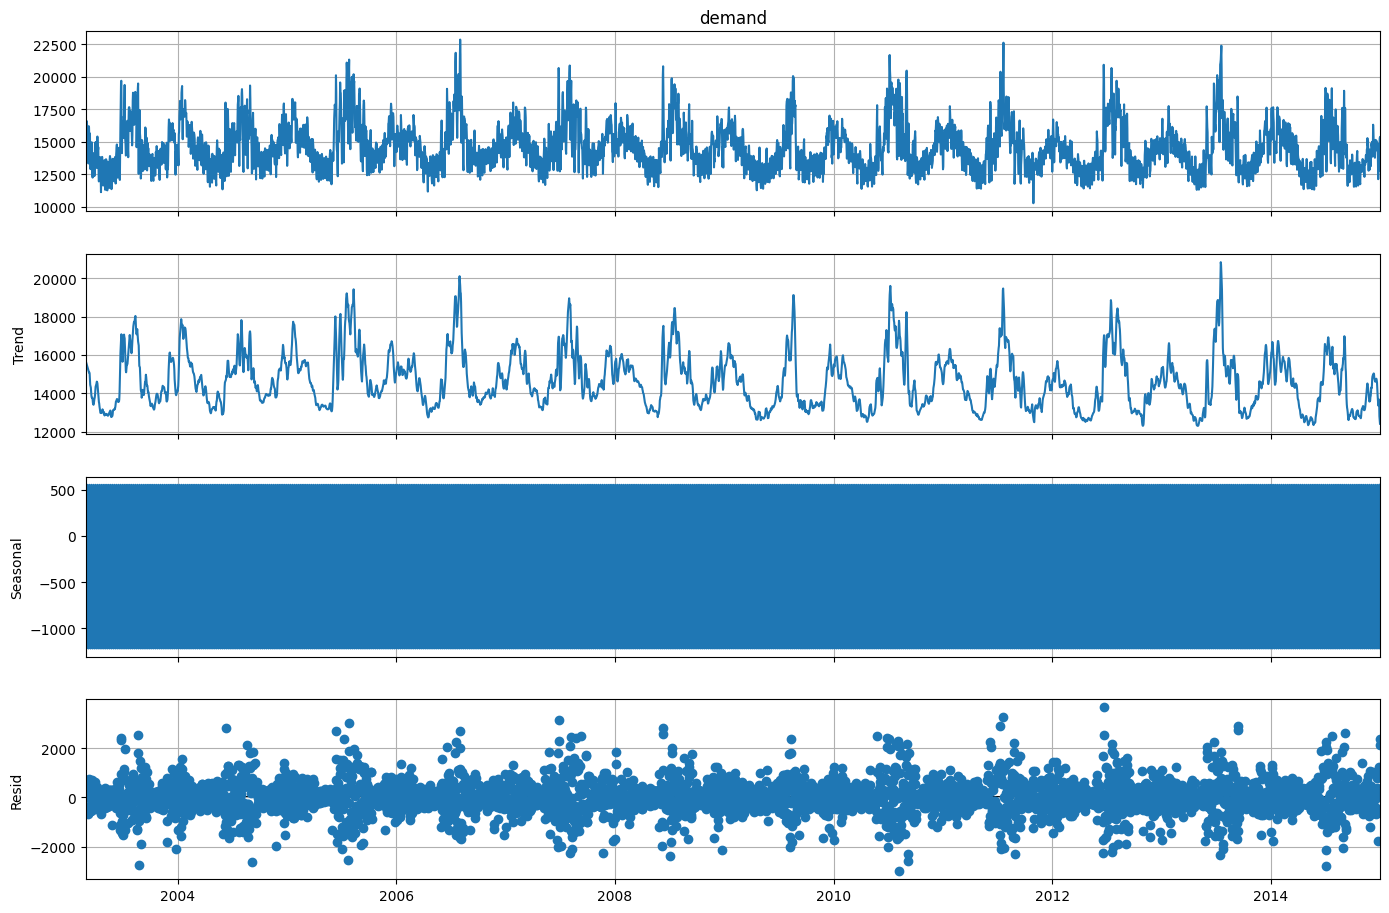

In [9]:
weekly_daily = daily.copy()

decomp = seasonal_decompose(weekly_daily, model="additive", period=7, extrapolate_trend="freq")
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.show()

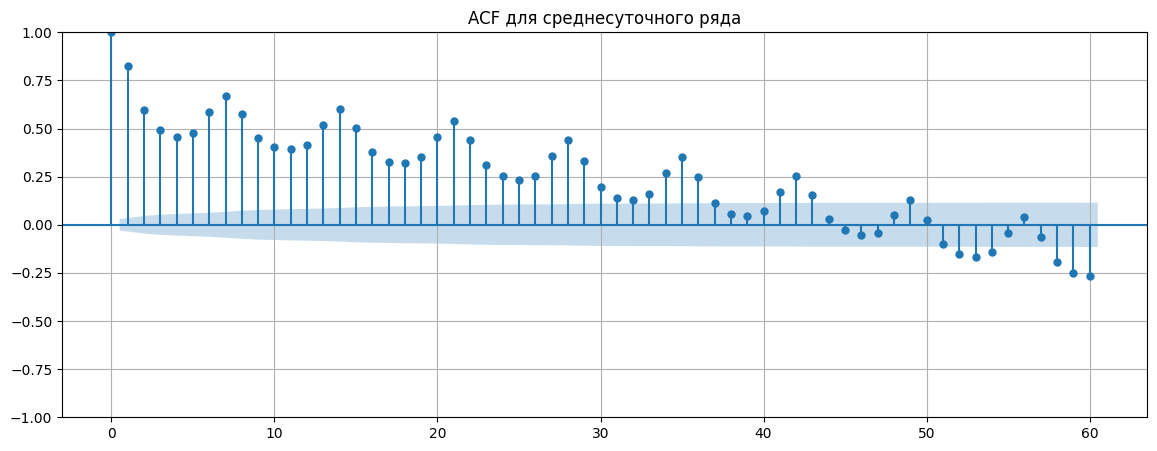

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(daily.dropna(), lags=60, ax=ax)
ax.set_title("ACF для среднесуточного ряда")
plt.show()

In [11]:
adf_raw = adfuller(prepared["demand"], maxlag=24, autolag=None)

print("ADF для исходного hourly ряда:")
print(f"  statistic = {adf_raw[0]:.6f}")
print(f"  p-value   = {adf_raw[1]:.6g}")
print(f"  used lag  = {adf_raw[2]}")
print(f"  nobs      = {adf_raw[3]}")

diff1 = prepared["demand"].diff().dropna()
adf_diff = adfuller(diff1, maxlag=24, autolag=None)

print("\nADF для ряда первой разности:")
print(f"  statistic = {adf_diff[0]:.6f}")
print(f"  p-value   = {adf_diff[1]:.6g}")
print(f"  used lag  = {adf_diff[2]}")
print(f"  nobs      = {adf_diff[3]}")

ADF для исходного hourly ряда:
  statistic = -30.469904
  p-value   = 0
  used lag  = 24
  nobs      = 103751

ADF для ряда первой разности:
  statistic = -52.995150
  p-value   = 0
  used lag  = 24
  nobs      = 103750
